In [1]:
import os
import sys
import gc
import math as m
import warnings

import numpy as np
import pandas as pd
import scipy
import scipy.interpolate
import pylab

from scipy import stats
from scipy.ndimage import gaussian_filter1d
from scipy.signal import butter, filtfilt, hilbert, find_peaks
from scipy.spatial.distance import jensenshannon
from scipy.stats import norm

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D

warnings.filterwarnings("ignore", category=RuntimeWarning)

sys.path.append('/projects/DEIKE/cmartinb/jupyter_notebook/project_specific/turbulence')
sys.path.append('/projects/DEIKE/cmartinb/functions')

from funciones import *

os.chdir('/projects/DEIKE/cmartinb/')

In [2]:
import os
graph_path = f'/projects/DEIKE/cmartinb/notebooks/graphs/PDF'
if not os.path.exists(graph_path):
    os.makedirs(graph_path)

In [3]:
import pylab
params = {'legend.fontsize': 'x-Large',
          'figure.figsize': (15, 6),
         'axes.labelsize': 30,
         'axes.titlesize':30,
         'xtick.labelsize':30,
         'ytick.labelsize':30,
    'font.family': 'STIXGeneral', 
    'axes.titleweight': 'normal',
    'axes.labelweight': 'normal',
    'text.usetex': True,
}

plt.rcParams.update(params)
pylab.rcParams.update(params)

In [5]:
# -----------------------------
# Helpers
# -----------------------------
def fmt_0p(x):
    return f"{x:.2f}".replace(".", "p")


def str0p_to_float(s):
    return float(s.replace("p", "."))


def load_eta_series(reA, Bo, kpHs, uoc, reW, maxLevel,
                    base="/projects/DEIKE/cmartinb/eta"):
    P = fmt_0p(kpHs)
    U = fmt_0p(uoc)
    path = f"{base}/eta_series_re{reA}_bo0{Bo}_P{P}_uoc{U}_reW{reW}_L{maxLevel}.npy"
    eta = np.load(path, allow_pickle=True)
    return eta, path


def pooled_eta_over_sigma(eta_series, step_snap=5, max_points=600_000, seed=0):
    rng = np.random.default_rng(seed)
    vals = []
    Nt = len(eta_series)

    for j in range(0, Nt, step_snap):
        eta_j = np.asarray(eta_series[j], float)
        eta_j -= np.nanmean(eta_j)
        v = eta_j.ravel()
        v = v[np.isfinite(v)]
        vals.append(v)

    vals = np.concatenate(vals)
    if vals.size > max_points:
        vals = vals[rng.choice(vals.size, size=max_points, replace=False)]

    sigma = np.std(vals)
    return vals / sigma


def pooled_eta_norm(
    eta_series, j0, j1,
    step_snap=5, max_points=600_000, seed=0,
    normalization="block"  # "block" or "snapshot"
):
    rng = np.random.default_rng(seed)
    vals = []

    for j in range(j0, j1, step_snap):
        eta_j = np.asarray(eta_series[j], float)
        eta_j -= np.nanmean(eta_j)
        v = eta_j.ravel()
        v = v[np.isfinite(v)]
        if v.size == 0:
            continue

        if normalization == "snapshot":
            s = np.std(v)
            if s > 0:
                v = v / s
            else:
                continue

        vals.append(v)

    if len(vals) == 0:
        return np.array([], dtype=float)

    vals = np.concatenate(vals)

    if vals.size > max_points:
        vals = vals[rng.choice(vals.size, size=max_points, replace=False)]

    if normalization == "block":
        s = np.std(vals) + 1e-30
        vals = vals / s

    return vals


def smooth_pdf(x, xlim=(-5, 5), nbins=140, smooth_sigma=1.2, pdf_floor_num=1e-12):
    counts, edges = np.histogram(x, bins=nbins, range=xlim, density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])
    pdf = gaussian_filter1d(counts, sigma=smooth_sigma)
    return centers, np.maximum(pdf, pdf_floor_num)


def symmetric_bins_from_data(x, nbins=140, abs_quantile=0.9995):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        raise ValueError("Empty array in symmetric_bins_from_data")

    xmax = np.quantile(np.abs(x), abs_quantile)
    if not np.isfinite(xmax) or xmax <= 0:
        xmax = np.max(np.abs(x))

    edges = np.linspace(-xmax, xmax, nbins + 1)
    return edges, xmax


def smooth_pdf_from_edges(x, edges, smooth_sigma=1.2, pdf_floor_num=1e-12):
    counts, _ = np.histogram(x, bins=edges, density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])
    pdf = gaussian_filter1d(counts, sigma=smooth_sigma)
    pdf = np.maximum(pdf, pdf_floor_num)
    return centers, pdf


def js_distance_from_edges(x1, x2, edges):
    """
    Jensen–Shannon
    """
    c1, _ = np.histogram(x1, bins=edges, density=False)
    c2, _ = np.histogram(x2, bins=edges, density=False)

    p = c1.astype(float) + 1e-15
    q = c2.astype(float) + 1e-15
    p /= p.sum()
    q /= q.sum()

    return jensenshannon(p, q, base=2.0)


def tayfun_pdf_eta_over_sigma(x, mu, pdf_floor=1e-12):
    x = np.asarray(x, float)
    mu = float(mu)

    if (not np.isfinite(mu)) or (mu <= 1e-10):
        p = norm.pdf(x, 0.0, 1.0)
        return np.maximum(p, pdf_floor)

    mu2 = mu**2
    p = np.full_like(x, np.nan, dtype=float)

    ok = (1.0 + 2.0 * mu * x) > 0.0
    if not np.any(ok):
        return p

    G = np.sqrt(1.0 + 2.0 * mu * x[ok]) - 1.0
    denom = np.sqrt(2.0 * np.pi * (1.0 + 3.0 * G + 2.0 * G**2))
    pref = (1.0 - 7.0 * mu2 / 8.0)

    p_ok = (pref / denom) * np.exp(-(G**2) / (2.0 * mu2))
    p_ok = np.maximum(p_ok, pdf_floor)

    p[ok] = p_ok
    return p


def load_time(reA, Bo, kpHs_str, uoc_str, reW, maxLevel):
    special_work_dirs = {
        ("0p04", "0p50"): (
            "/projects/DEIKE/cmartinb/cases_multiphase_broadbanded/"
            "re720_bo200_kpHs0p04_uoc0p50_reW2.5e4_L10/"
        )
    }

    work_dir_default = (
        f"/projects/DEIKE/nscapin/broadband_reorder/"
        f"re{reA}_bo0{Bo}_P{kpHs_str}_uoc{uoc_str}_reW{reW}_L{maxLevel}/"
    )

    work_dir = special_work_dirs.get((kpHs_str, uoc_str), work_dir_default)

    data = np.loadtxt(work_dir + "eta/global_int.out")
    time = data[:, 0]
    return time, work_dir


def sigma_eta_snapshot(eta2d):
    eta2d = np.asarray(eta2d, float)
    eta2d -= np.nanmean(eta2d)
    v = eta2d.ravel()
    v = v[np.isfinite(v)]
    return np.std(v)


def interval_means(x, y, nbins=6):
    xmin, xmax = float(x.min()), float(x.max())
    edges = np.linspace(xmin, xmax, nbins + 1)
    xplot, yplot = [], []
    for a, b in zip(edges[:-1], edges[1:]):
        m = (x >= a) & (x < b)
        if not np.any(m):
            continue
        xplot.append(np.mean(x[m]))
        yplot.append(np.mean(y[m]))
    return np.array(xplot), np.array(yplot)

In [6]:
# -----------------------------
# CONFIG
# -----------------------------
reA = 720
Bo  = 200
reW = "2.5e4"
maxLevel = 10

kp = 4
u = 0.25
lambdap = 2*m.pi/kp
rho1 = 1
rho2 = 1.25e-3
L0 = 2*np.pi

tstart = 0.0
nbins = 6

# -----------------------------
# PDF params
# -----------------------------
nbins = 140
smooth_sigma = 1.2
pdf_floor_plot = 1e-6
pdf_floor_num  = 1e-12

step_snap  = 5
max_points = 600_000

abs_quantile_for_bins = 0.9995

normalization = "snapshot"  # "block" "snapshot"

xlim_plot = (-8, 8)  

In [7]:
kpHs_list = [0.08, 0.16, 0.04]
uoc_list  = [0.25, 0.50]
cases = [(kpHs, uoc) for kpHs in kpHs_list for uoc in uoc_list if not (kpHs == 0.04 and uoc == 0.25)]

case_colors = {
    (0.16, 0.25): "purple",
    (0.16, 0.50): "red",
    (0.08, 0.25): "green",
    (0.08, 0.50): "navy",
    (0.04, 0.50): "orange",
}

max_points     = 10_000_000 
pdf_floor_plot = 1e-12        

<Figure size 1500x1000 with 0 Axes>

Loaded: /projects/DEIKE/cmartinb/eta/eta_series_re720_bo0200_P0p08_uoc0p25_reW2.5e4_L10.npy | Nt = 1337
Loaded: /projects/DEIKE/cmartinb/eta/eta_series_re720_bo0200_P0p08_uoc0p50_reW2.5e4_L10.npy | Nt = 1731
Loaded: /projects/DEIKE/cmartinb/eta/eta_series_re720_bo0200_P0p16_uoc0p25_reW2.5e4_L10.npy | Nt = 1158
Loaded: /projects/DEIKE/cmartinb/eta/eta_series_re720_bo0200_P0p16_uoc0p50_reW2.5e4_L10.npy | Nt = 1246
Loaded: /projects/DEIKE/cmartinb/eta/eta_series_re720_bo0200_P0p04_uoc0p50_reW2.5e4_L10.npy | Nt = 1410


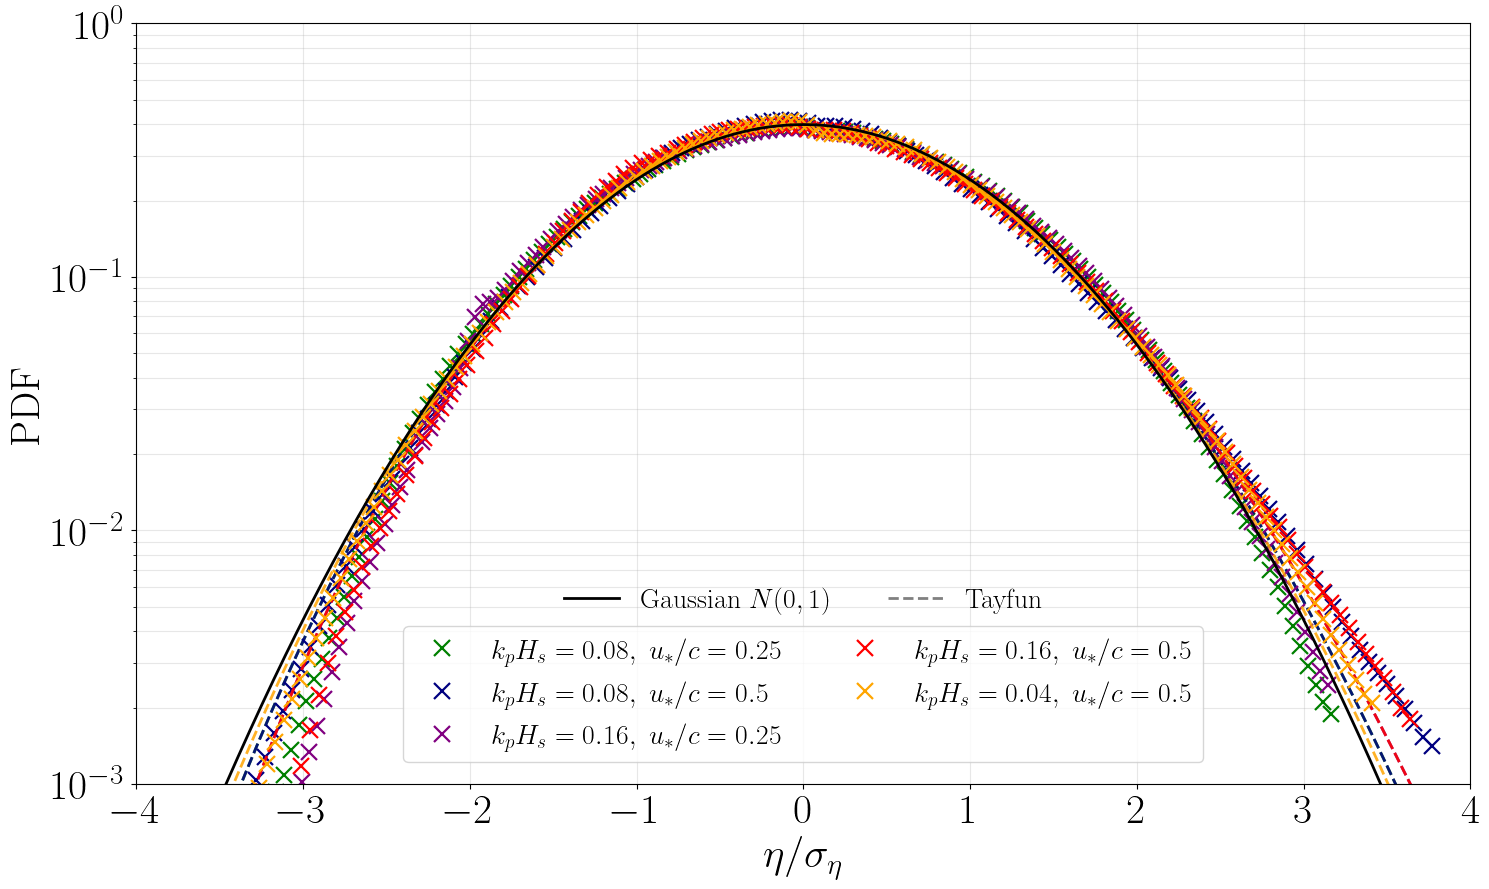

Saved: /projects/DEIKE/cmartinb/notebooks/graphs/PDF/PDF_eta_over_sigma_compare_ALLcases_logy_with_Tayfun.pdf


In [8]:
# =========================================================
# Tayfun PDF (x = eta/sigma_eta)
# =========================================================
def tayfun_pdf_eta_over_sigma(x, mu, pdf_floor=1e-12):
    x  = np.asarray(x, float)
    mu = float(mu)
    mu2 = mu**2

    p = np.full_like(x, np.nan, dtype=float)

    ok = (1.0 + 2.0*mu*x) > 0.0
    if not np.any(ok):
        return p

    G = np.sqrt(1.0 + 2.0*mu*x[ok]) - 1.0
    denom = np.sqrt(2.0*np.pi*(1.0 + 3.0*G + 2.0*G**2))
    pref  = (1.0 - 7.0*mu2/8.0)

    p_ok = (pref/denom) * np.exp(-(G**2)/(2.0*mu2))
    p_ok = np.maximum(p_ok, pdf_floor)

    p[ok] = p_ok
    return p


plt.figure(figsize=(15, 9))

case_colors = {
    (0.16, 0.25): "purple",
    (0.16, 0.50): "red",
    (0.08, 0.25): "green",
    (0.08, 0.50): "navy",
    (0.04, 0.50): "orange",
}

for i, (kpHs, uoc) in enumerate(cases):
    
    color = case_colors[(kpHs, uoc)]

    eta, path = load_eta_series(reA, Bo, kpHs, uoc, reW, maxLevel)
    Nt = len(eta)
    print("Loaded:", path, "| Nt =", Nt)

    b1 = Nt // 3
    b2 = 2 * Nt // 3

    x_use = pooled_eta_norm(
        eta, b1, Nt,
        step_snap=step_snap,
        max_points=max_points,
        seed=i,
        normalization=normalization
    )

    edges, xmax = symmetric_bins_from_data(
        x_use, nbins=nbins, abs_quantile=abs_quantile_for_bins
    )

    centers, pdf = smooth_pdf_from_edges(
        x_use, edges,
        smooth_sigma=smooth_sigma,
        pdf_floor_num=pdf_floor_num
    )

    mask = pdf >= pdf_floor_plot

    plt.semilogy(
        centers[mask], pdf[mask],
        linestyle='None',
        marker='x',
        markersize=12,
        markeredgewidth=1.6,
        color=color,
        label=rf'$k_pH_s={kpHs},\ u_\ast/c={uoc}$'
    )

    mu = float(kpHs) / 4.0

    x_ref = np.linspace(-8, 8, 900)
    pdf_t = tayfun_pdf_eta_over_sigma(x_ref, mu, pdf_floor=pdf_floor_num)
    m_t = np.isfinite(pdf_t) & (pdf_t >= pdf_floor_plot)

    plt.semilogy(
        x_ref[m_t], pdf_t[m_t],
        lw=2.0,
        ls='--',
        alpha=0.85,
        color=color
    )


x_ref_g = np.linspace(-8, 8, 900)
pdf_g = np.maximum(norm.pdf(x_ref_g, 0.0, 1.0), pdf_floor_num)

gauss_line, = plt.semilogy(
    x_ref_g, pdf_g,
    'k-', lw=2,
    label=r'Gaussian $N(0,1)$'
)

plt.xlim(-4, 4)
plt.ylim(1e-3, 1)
plt.xlabel(r'$\eta/\sigma_{\eta}$' if normalization == "snapshot"
           else r'$\eta/\sigma_{\eta,\mathrm{block}}$')
plt.ylabel('PDF')
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()

handles, labels = plt.gca().get_legend_handles_labels()

case_handles = []
case_labels  = []
gauss_handle = None
gauss_label  = None

for h, l in zip(handles, labels):
    if 'Gaussian' in l:
        gauss_handle = h
        gauss_label  = l
    else:
        case_handles.append(h)
        case_labels.append(l)

# --- Leyenda 1: CASOS ---
leg1 = plt.legend(
    case_handles,
    case_labels,
    ncol=2,
    frameon=True,
    fontsize=20,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.01)
)
plt.gca().add_artist(leg1)

tayfun_proxy = Line2D(
    [0], [0],
    color='gray',
    lw=2,
    ls='--'
)

plt.legend(
    [gauss_handle, tayfun_proxy],
    [gauss_label, r'Tayfun'],
    frameon=False,
    fontsize=20,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.19),
    ncol=2
)

out = f"{graph_path}/PDF_eta_over_sigma_compare_ALLcases_logy_with_Tayfun.pdf"
plt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print("Saved:", out)


case kpHs=0p08, uoc=0p25: omegap=4, Tp=1.5708, max(t/Tp)=41.75

================ CASE CHECK ================
case: kpHs='0p08' (nom=0.080), uoc='0p25' (u*/c=0.250)
omega_p = 4   Tp = 1.5708
trim: idx0=0   Nt_total=1337   Nt_after_trim=1337
sigma_eta: mean=4.7769e-03  std=8.9780e-05  min=4.6234e-03  max=4.9986e-03
kpHs(t)=4kp*sigma: mean=0.0764  std=0.0014  min=0.0740  max=0.0800
ratio mean/nominal: 0.955
case kpHs=0p08, uoc=0p50: omegap=2, Tp=3.1416, max(t/Tp)=54.06

================ CASE CHECK ================
case: kpHs='0p08' (nom=0.080), uoc='0p50' (u*/c=0.500)
omega_p = 2   Tp = 3.14159
trim: idx0=0   Nt_total=1731   Nt_after_trim=1731
sigma_eta: mean=8.8968e-03  std=2.9351e-03  min=4.6430e-03  max=1.5065e-02
kpHs(t)=4kp*sigma: mean=0.1423  std=0.0470  min=0.0743  max=0.2410
ratio mean/nominal: 1.779
case kpHs=0p16, uoc=0p25: omegap=4, Tp=1.5708, max(t/Tp)=36.16

================ CASE CHECK ================
case: kpHs='0p16' (nom=0.160), uoc='0p25' (u*/c=0.250)
omega_p = 4   Tp = 

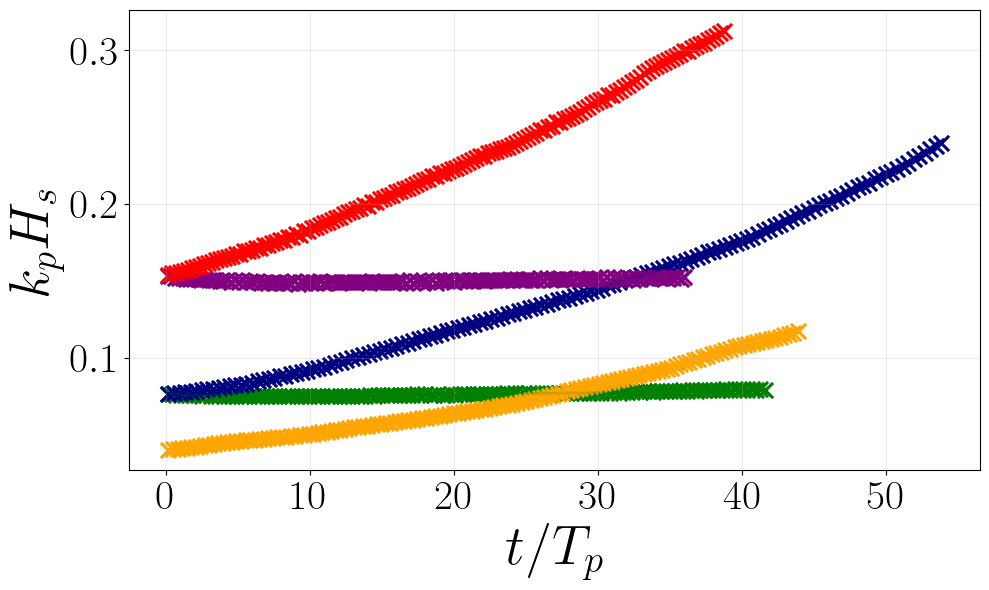

In [9]:
# =========================================================
# CASES (STRINGS)
# =========================================================

kpHs_list = ["0p08", "0p16", "0p04"]
uoc_list  = ["0p25", "0p50"]
cases = [(kpHs, uoc) for kpHs in kpHs_list for uoc in uoc_list if not (kpHs == "0p04" and uoc == "0p25")]

case_colors = {
    ("0p16", "0p25"): "purple",
    ("0p16", "0p50"): "red",
    ("0p08", "0p25"): "green",
    ("0p08", "0p50"): "navy",
    ("0p04", "0p50"): "orange",
}

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(10, 6))
jitter = np.linspace(-0.3, 0.3, len(cases)) * 0.06  # en unidades de t/Tp

# =========================================================
# RECORTE
# =========================================================

max_points     = 10_000_000
pdf_floor_plot = 1e-12


for icase, (kpHs_str, uoc_str) in enumerate(cases):

    color = case_colors[(kpHs_str, uoc_str)]

    ak, c, omegap, nu_water, g, uoc_val, sigma_surf, Tp = calculate_parameters(
        kpHs_str, uoc_str, u, kp, Bo, rho1, rho2
    )

    kpHs_float = str0p_to_float(kpHs_str)
    uoc_float  = str0p_to_float(uoc_str)
    eta_series, eta_path = load_eta_series(reA, Bo, kpHs_float, uoc_float, reW, maxLevel)

    time, work_dir = load_time(reA, Bo, kpHs_str, uoc_str, reW, maxLevel)

    Nt = min(len(eta_series), len(time))
    eta_series = eta_series[:Nt]
    time = time[:Nt]

    cond = omegap * (time - tstart) > 5
    idx0 = np.argmax(cond) if np.any(cond) else 0

    eta_series = eta_series[idx0:]
    time = time[idx0:]
    if len(time) == 0:
        print(f"WARNING empty after trim: kpHs={kpHs_str}, uoc={uoc_str}")
        continue

    tTp = (time - time[0]) / Tp

    sigmas = np.array([sigma_eta_snapshot(e) for e in eta_series])
    kpHs_t = 4.0 * kp * sigmas

    xplot, yplot = interval_means(tTp, kpHs_t, nbins=nbins)

    plt.scatter(
        xplot + jitter[icase], yplot,
        marker='x', s=120, linewidths=2.2,
        color=color,
        label=rf'$k_pH_s={kpHs_float}$, $u_\ast/c={uoc_float}$'
    )
    plt.plot(xplot + jitter[icase], yplot, alpha=0.2, lw=2, color=color)

    print(f"case kpHs={kpHs_str}, uoc={uoc_str}: omegap={omegap:.5g}, Tp={Tp:.5g}, max(t/Tp)={tTp.max():.2f}")

    sigma_mean = float(np.mean(sigmas))
    sigma_std  = float(np.std(sigmas))
    sigma_min  = float(np.min(sigmas))
    sigma_max  = float(np.max(sigmas))

    kpHs_mean = float(np.mean(kpHs_t))
    kpHs_std  = float(np.std(kpHs_t))
    kpHs_min  = float(np.min(kpHs_t))
    kpHs_max  = float(np.max(kpHs_t))

    print("\n================ CASE CHECK ================")
    print(f"case: kpHs='{kpHs_str}' (nom={kpHs_float:.3f}), uoc='{uoc_str}' (u*/c={uoc_float:.3f})")
    print(f"omega_p = {omegap:.6g}   Tp = {Tp:.6g}")
    print(f"trim: idx0={idx0}   Nt_total={Nt}   Nt_after_trim={len(tTp)}")
    print(f"sigma_eta: mean={sigma_mean:.4e}  std={sigma_std:.4e}  min={sigma_min:.4e}  max={sigma_max:.4e}")
    print(f"kpHs(t)=4kp*sigma: mean={kpHs_mean:.4f}  std={kpHs_std:.4f}  min={kpHs_min:.4f}  max={kpHs_max:.4f}")
    print(f"ratio mean/nominal: {kpHs_mean/kpHs_float:.3f}")
    print("============================================")

plt.xlabel(r'$t/T_p$',fontsize = 40)
plt.ylabel(r'$k_pH_s$',fontsize = 40)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(graph_path + '/kpHs.pdf', dpi=300, bbox_inches='tight')
plt.show()